This notebook runs the reduced-order model (ROM) experiments for the parametric heat equation.

The full-order model (FOM) is a finite element discretization of the 2D heat equation on $[0, 2\pi]^2$ with uniform diffusion coefficient and homogeneous Dirichlet boundary conditions, starting from zero initial conditions. The system is forced by a spatially localized Gaussian source centered at $(x_0, y_0)$ with a $\sin(x/2)\sin(y/2)$ envelope and amplitude $\varepsilon$, decaying exponentially in time as $e^{-t}$. The three parameters are $\mu = (\varepsilon, x_0, y_0)$, with 160 training and 40 test samples over $t \in [0, \pi]$.

A Tucker decomposition of the snapshot tensor is used to build parameter-dependent reduced bases. Three basis construction methods are compared:
- **Monolithic**: a single global SVD basis computed from all training snapshots
- **Radial Basis Functions (RBF)**: a parameter-interpolated basis using Gaussian RBF weights on the Tucker parameter factor
- **Mamonov/Olshanskii (MO)**: a locally informed basis using MO interpolation weights

ROM errors and projection errors are reported across a sweep of basis sizes and Tucker core ranks.

# Scripts

In [1]:
# Generate FOM snapshots and save to disk
!python generate_data.py

Saving to: data/Heat
Total sampled parameters:  200
Training parameters:  160
Single sample run: 
Parametric heat equation finite element model
  Spatial domain (2D): [0, 6.2832] x [0, 6.2832]
  Discretization size: 1210
  Degrees of freedom:  1082
Run for all parameters:
no more timer available (lff_from_py), reusing last one


In [2]:
# Compute Tucker decomposition of snapshot tensor
!python tucker.py

Saving to: data/Heat
Loading data
X.shape=(1082, 1201, 160)
Tucker
reconstruction error=0.032161601966442896, variation=3.0885036418210055e-06.
converged in 2 iterations.
reconstruction error=0.00620829922374019, variation=8.39305649426303e-06.
converged in 2 iterations.
Tucker
reconstruction error=0.00032552537720152144, variation=9.47213763983568e-09.
converged in 2 iterations.
SVD
Saving SVD


# Imports

In [3]:
# Core imports and path/directory setup
import os
import sys
import numpy as np
import tensorly as tl

sys.path.insert(0, os.path.abspath("../.."))
savedir = "../../data/Heat"

In [4]:
# Problem-specific imports
import scipy.sparse as sp
from tensorly.tucker_tensor import TuckerTensor
from src.Heat.ROM import *
from src.Heat.FOM import HeatFEM2D
from src.Utils.utils import *
from src.Bases.rbf import RBFWeights
from src.Bases.mo import mo
import matplotlib.pyplot as plt

In [5]:
# LaTeX matplotlib style
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
    "font.size": 20,
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

# Load data

In [6]:
# Time grid, FOM initialization, and mass matrix
t = np.linspace(0, np.pi, 1201)
fom = HeatFEM2D(L=2 * np.pi, h=0.2, order=1)
M_Q = fom.M

In [7]:
# Load training/test parameters and snapshots
with np.load(os.path.join(savedir, "params_train.npz")) as z:
    params_train = z["params"]
with np.load(os.path.join(savedir, "params_test.npz")) as z:
    params_test = z["params"]

with np.load(os.path.join(savedir, "heat_train.npz")) as z:
    snapshots_Q_train = z["Q"]

with np.load(os.path.join(savedir, "heat_test.npz")) as z:
    snapshots_Q_test = z["Q"]

snapshots_Q_train.shape, snapshots_Q_test.shape, params_train.shape, params_test.shape

((160, 1082, 1201), (40, 1082, 1201), (160, 3), (40, 3))

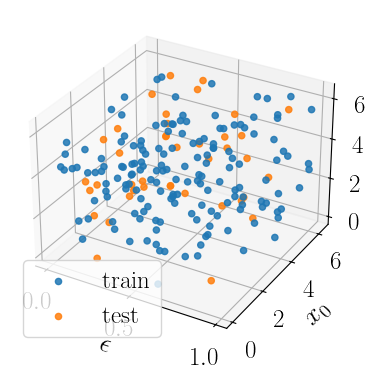

In [8]:
# Scatter plot of train/test parameter distribution
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(params_train[:,0], params_train[:,1], params_train[:,2],
           c="tab:blue", s=20, alpha=0.85, label="train")
ax.scatter(params_test[:,0],  params_test[:,1],  params_test[:,2],
           c="tab:orange", s=20, alpha=0.85, label="test")
ax.set_xlabel(r"$\epsilon$"); ax.set_ylabel("$x_0$"); ax.set_zlabel("$y_0$")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Load monolithic SVD basis and verify M-orthonormality
data = np.load(os.path.join(savedir, "svd_rank120_Mortho.npz"))
U_mono, S_mono = data["U"], data["S"]
print("Check for MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_mono.T @ M_Q @ U_mono - np.eye(U_mono.shape[1])))

Check for MW-orthonormality: ||U^T MW U - I|| = 2.7965896181545328e-14


In [10]:
# Load Tucker decomposition
core, factors = load_tucker_npz(os.path.join(savedir, "tucker_120x120x120_Mortho.npz"))
tucker_tensor = TuckerTensor((core, factors))
print("Tucker shape:", tucker_tensor.shape)

Tucker shape: (1082, 1201, 160)


In [11]:
# ROM rank values to sweep
r_arr = np.array([1, 5, 10, 20, 30, 40, 50, 60], dtype=int)

# Single parameter predictions

In [ ]:
# Select a single test parameter for the experiments
idx       = 8

r_idx_rbf = 2
r_idx_mo = 2
r_idx_mono = 2

mu = params_test[idx]   # [omega, x0, y0]
print(f"mu: eps={mu[0]:.3f}, x0={mu[1]:.3f}, y0={mu[2]:.3f}")

mu: eps=0.334, x0=5.807, y0=5.418


In [25]:
# Initialize Radial Basis Function interpolant on training parameters
rbfw = RBFWeights(
    mus=params_train,
    basis="gaussian",
    eps=1,
    order=-1,
    nugget=0,
)

In [14]:
# Build RBF basis, solve ROM, compute projection and ROM errors
W_rbf = rbfw.weights(params_test[idx])
U_rbf, s_rbf, _ = buildParBasis(tucker_tensor, W_rbf)

print("MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_rbf.T @ M_Q @ U_rbf - np.eye(U_rbf.shape[1])))
print("Projection error  :", projection_error_M(snapshots_Q_test[idx],
      U_rbf[:, :r_arr[r_idx_rbf]], M_Q, Mnorm))

ROM_rbf = HeatPODROM(fom, U_rbf[:, :r_arr[r_idx_rbf]])
Qr_rbf, Ur_rbf = ROM_rbf.solve(mu[0], mu[1], mu[2], t)
Q_rbf = Ur_rbf @ Qr_rbf

print("ROM error (MW)    :",
      Mnorm(snapshots_Q_test[idx] - Q_rbf, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))
U_rbf[:, :r_arr[r_idx_rbf]].shape

MW-orthonormality: ||U^T MW U - I|| = 3.350141613726955e-14
Projection error  : 0.11282754661874198
ROM error (MW)    : 0.11550286468221073


(1082, 10)

In [15]:
# Solve ROM with monolithic basis, compute errors
ROM_mono = HeatPODROM(fom, U_mono[:, :r_arr[r_idx_mono]])
Qr_mono, Ur_mono = ROM_mono.solve(mu[0], mu[1], mu[2], t)
Q_mono = Ur_mono @ Qr_mono

print("MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(Ur_mono.T @ M_Q @ Ur_mono - np.eye(Ur_mono.shape[1])))
print("Projection error  :", projection_error_M(snapshots_Q_test[idx],
      Ur_mono, M_Q, Mnorm))
print("ROM error (MW)    :",
      Mnorm(snapshots_Q_test[idx] - Q_mono, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))

MW-orthonormality: ||U^T MW U - I|| = 4.22581895049337e-15
Projection error  : 0.6860302655999321
ROM error (MW)    : 0.7107849653162862


In [16]:
# Build MO basis, solve ROM, compute errors
W_mo = mo(params_train, 15, params_test[idx], eps=1e-16, rcond=1e-16)
U_mo, s_mo, _ = buildParBasis(tucker_tensor, W_mo)

print("MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_mo[:, :r_arr[r_idx_mo]].T @ M_Q @ U_mo[:, :r_arr[r_idx_mo]] - np.eye(r_arr[r_idx_mo])))
print("Projection error  :", projection_error_M(snapshots_Q_test[idx],
      U_mo[:, :r_arr[r_idx_mo]], M_Q, Mnorm))

ROM_mo = HeatPODROM(fom, U_mo[:, :r_arr[r_idx_mo]])
Qr_mo, Ur_mo = ROM_mo.solve(mu[0], mu[1], mu[2], t)
Q_mo = Ur_mo @ Qr_mo

print("ROM error (MW)    :",
      Mnorm(snapshots_Q_test[idx] - Q_mo, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))

MW-orthonormality: ||U^T MW U - I|| = 4.585869832434766e-15
Projection error  : 0.14635881940446652
ROM error (MW)    : 0.14914206862574053


## Plots

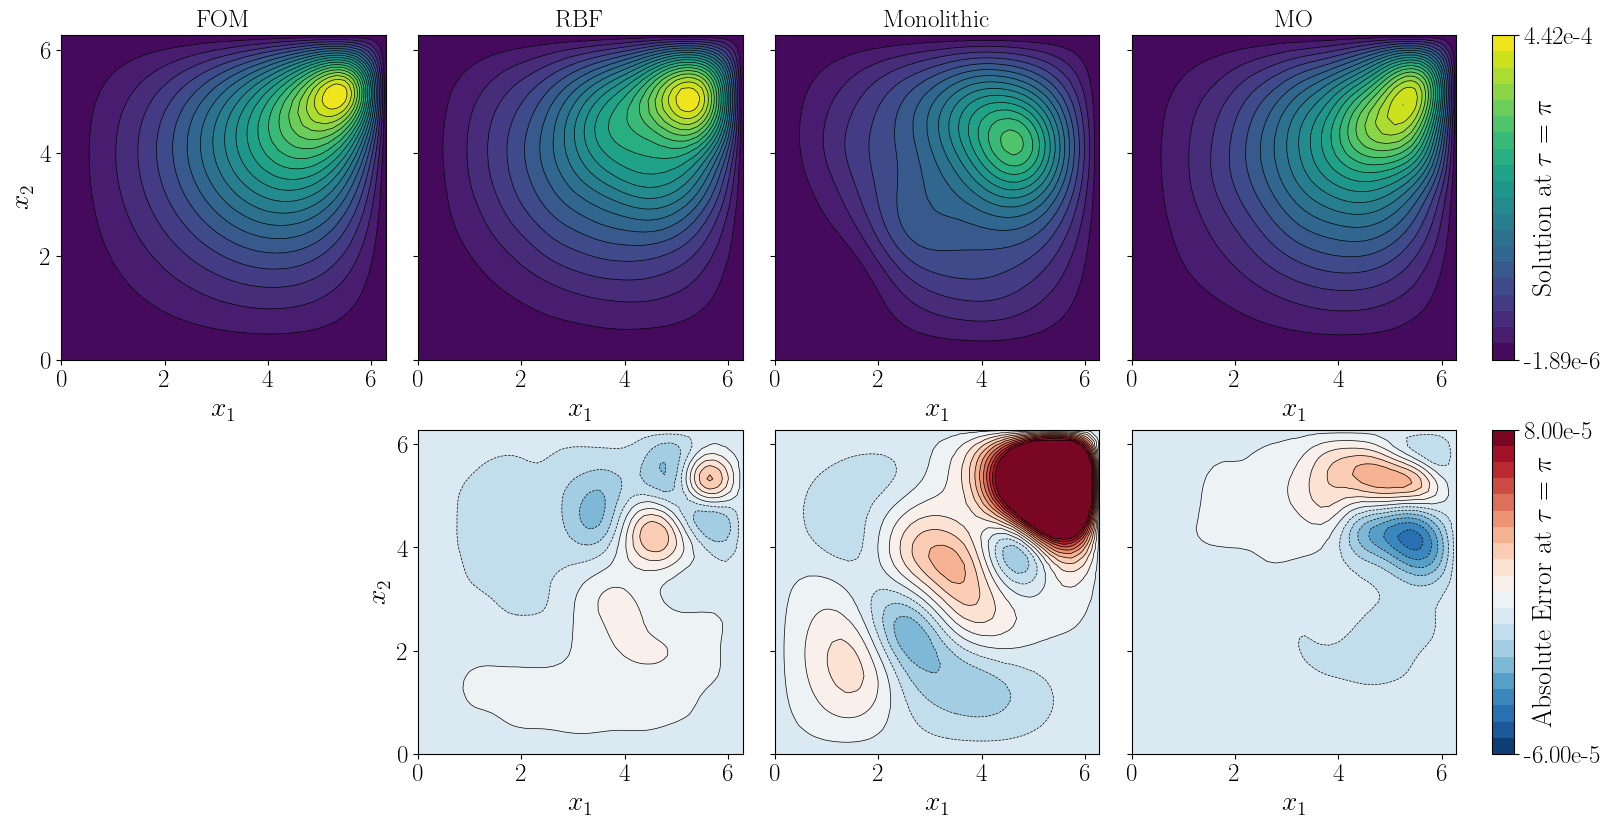

In [17]:
# Plot FOM vs ROM solution contours and absolute errors
from src.Heat.plots import eval_grid, plot_contours

t_idx = -1

Z_fom  = eval_grid(fom, snapshots_Q_test[idx][:, t_idx])
Z_rbf  = eval_grid(fom, Q_rbf[:, t_idx])
Z_mono = eval_grid(fom, Q_mono[:, t_idx])
Z_mo  = eval_grid(fom, Q_mo[:, t_idx])

plot_contours(fom, Z_fom, Z_rbf, Z_mono, Z_mo,
              sol_label=rf"Solution at $\tau = \pi$",
              err_label=rf"Absolute Error at $\tau = \pi$",
            nlevels=20, eclims=[-6e-5, 8e-5])
plt.savefig("solution_heat.pdf", bbox_inches='tight')
plt.show()

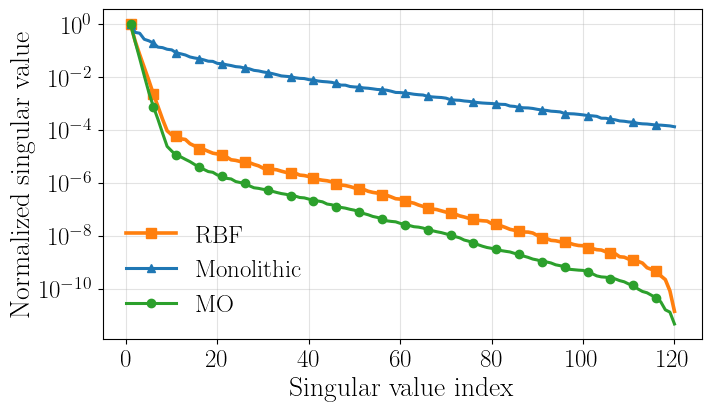

In [18]:
# Plot singular value decay for all three bases
from src.Heat.plots import plot_singular_values
plot_singular_values(s_rbf, S_mono, s_mo)
plt.savefig("singular_values_heat.pdf", bbox_inches='tight')
plt.show()

# Parameter sweep

In [19]:
# Error sweep function and per-method basis builders
def heat_sweep_dataset(fom, params, r_arr, snapshots_Q, t, M_Q,
                       basis_builder, label=""):
    """ROM and projection-error sweep over a dataset.

    Returns
    -------
    rom_Q  : (len(r_arr), n_cases) – relative M ROM error
    proj_Q : (len(r_arr), n_cases) – relative M projection error
    """
    r_arr   = np.asarray(r_arr, dtype=int)
    rmax    = int(np.max(r_arr))
    n_cases = params.shape[0]

    rom_Q  = np.zeros((len(r_arr), n_cases))
    proj_Q = np.zeros((len(r_arr), n_cases))

    for idx in range(n_cases):
        mu      = params[idx]
        Q_truth = snapshots_Q[idx]          # (Nx_free, Nt)
        denom   = Mnorm(Q_truth, M_Q)

        U_max = basis_builder(mu, rmax)
        ROM   = HeatPODROM(fom, U_max)

        for r_idx, r in enumerate(r_arr):
            Qr, Ur = ROM.solve(mu[0], mu[1], mu[2], t, r=int(r))
            Q_full = Ur @ Qr
            rom_Q [r_idx, idx] = Mnorm(Q_truth - Q_full, M_Q) / denom
            proj_Q[r_idx, idx] = projection_error_M(Q_truth, Ur, M_Q, Mnorm)

        if label:
            print(f"{label}: {idx+1}/{n_cases}", end="\r")
    print()
    return rom_Q, proj_Q


# Basis builders (return (Nx_free, rmax) basis for a given mu)
def build_mono(mu, rmax):
    return U_mono[:, :rmax]

def build_rbf(mu, rmax):
    W = rbfw.weights(mu)
    U, _, _ = buildParBasis(tucker_tensor, W)
    return U[:, :rmax]

def build_mo(mu, rmax, k=15, eps=1e-16, rcond=1e-16):
    W = mo(params_train, k, mu, eps=eps, rcond=rcond)
    U, _, _ = buildParBasis(tucker_tensor, W)
    return U[:, :rmax]


In [20]:
# Sweep errors over the test set
mono_rom_te, mono_proj_te = heat_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, t, M_Q, build_mono, label="mono test")

rbf_rom_te, rbf_proj_te = heat_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, t, M_Q, build_rbf, label="rbf test")

mo_rom_te, mo_proj_te = heat_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, t, M_Q, build_mo, label="mo test")

mono test: 40/40
rbf test: 40/40
mo test: 40/40


In [21]:
# Sweep errors over the training set
mono_rom_tr, mono_proj_tr = heat_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, t, M_Q, build_mono, label="mono train")

rbf_rom_tr, rbf_proj_tr = heat_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, t, M_Q, build_rbf, label="rbf train")

mo_rom_tr, mo_proj_tr = heat_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, t, M_Q, build_mo, label="mo train")

mono train: 160/160
rbf train: 160/160
mo train: 160/160


In [22]:
# Save all sweep results to disk
np.savez(
    os.path.join(savedir, "errors_120x120x120.npz"),
    r_arr=r_arr,
    params_train=params_train,
    params_test=params_test,

    mono_rom_train=mono_rom_tr,  mono_proj_train=mono_proj_tr,
    mono_rom_test=mono_rom_te,   mono_proj_test=mono_proj_te,

    rbf_rom_train=rbf_rom_tr,    rbf_proj_train=rbf_proj_tr,
    rbf_rom_test=rbf_rom_te,     rbf_proj_test=rbf_proj_te,

    mo_rom_train=mo_rom_tr,    mo_proj_train=mo_proj_tr,
    mo_rom_test=mo_rom_te,     mo_proj_test=mo_proj_te,
)

/Users/arjunveejay/Documents/Code/Private repos/TuckerROMs/src/Heat/plots.py:73: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.16)


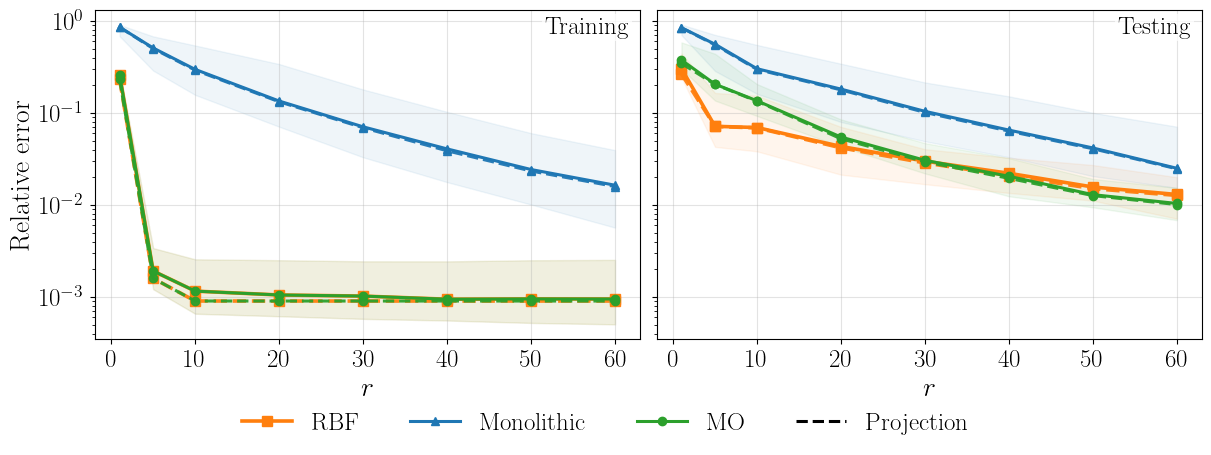

In [23]:
# Plot ROM and projection error curves for Tucker rank (120, 120, 120)
from src.Heat.plots import plot_errors
errs = np.load(os.path.join(savedir, "errors_120x120x120.npz"))
plot_errors(errs)
plt.savefig("errors_heat.pdf", bbox_inches='tight')
plt.show()


In [24]:
# Median projection error at largest basis size, across Tucker core sizes and methods
X_orig   = snapshots_Q_train.transpose(1, 2, 0)
X_mat    = X_orig.reshape(X_orig.shape[0], -1)
X_norm_M = Mnorm(X_mat, M_Q)

tucker_configs = [
    ("30x30x30",    "tucker_30x30x30_Mortho.npz",    30),
    ("60x60x60",    "tucker_60x60x60_Mortho.npz",    60),
    ("120x120x120", "tucker_120x120x120_Mortho.npz", 120),
]

print(f"{'Tucker rank':<15}  {'Recon error':>12}  {'Method':<12}  {'Train':>10}  {'Test':>10}")
print("-" * 68)

for rank_str, npz_file, rmax in tucker_configs:
    c, f = load_tucker_npz(os.path.join(savedir, npz_file))
    tt = TuckerTensor((c, f))

    X_rec   = tl.tucker_to_tensor((c, f))
    E_mat   = (X_orig - X_rec).reshape(X_orig.shape[0], -1)
    recon   = Mnorm(E_mat, M_Q) / X_norm_M

    bases = {
        "Monolithic": lambda mu, tt=tt, r=rmax: U_mono[:, :r],
        "RBF":        lambda mu, tt=tt, r=rmax: buildParBasis(tt, rbfw.weights(mu))[0][:, :r],
        "MO":         lambda mu, tt=tt, r=rmax: buildParBasis(tt, mo(params_train, 15, mu, eps=1e-16, rcond=1e-16))[0][:, :r],
    }

    for i, (method, builder) in enumerate(bases.items()):
        tr = np.median([projection_error_M(snapshots_Q_train[j], builder(params_train[j]), M_Q, Mnorm)
                        for j in range(len(params_train))])
        te = np.median([projection_error_M(snapshots_Q_test[j],  builder(params_test[j]),  M_Q, Mnorm)
                        for j in range(len(params_test))])
        recon_str = f"{recon:.4e}" if i == 0 else ""
        print(f"{rank_str:<15}  {recon_str:>12}  {method:<12}  {tr:>10.4e}  {te:>10.4e}")
    print()


Tucker rank       Recon error  Method             Train        Test
--------------------------------------------------------------------
30x30x30           3.2162e-02  Monolithic    6.9086e-02  1.0129e-01
30x30x30                       RBF           6.9105e-02  1.0139e-01
30x30x30                       MO            6.9105e-02  1.0139e-01

60x60x60           6.2083e-03  Monolithic    1.5852e-02  2.4694e-02
60x60x60                       RBF           1.5626e-02  2.5946e-02
60x60x60                       MO            1.5626e-02  2.5946e-02

120x120x120        3.2553e-04  Monolithic    9.0248e-04  3.7405e-03
120x120x120                    RBF           9.0169e-04  3.7351e-03
120x120x120                    MO            9.0169e-04  3.7351e-03

